In [105]:
import sys
!{sys.executable} -m pip install -q snowflake-connector-python pandas scikit-learn matplotlib


In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import snowflake.connector
from sklearn.metrics import mean_absolute_error
import seaborn as sns
from dotenv import load_dotenv
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import numpy as np
from sklearn.impute import SimpleImputer








In [107]:


load_dotenv()  
conn = snowflake.connector.connect(
    user=os.getenv("SNOWFLAKE_USER"),
    password=os.getenv("SNOWFLAKE_PASSWORD"),
    account=os.getenv("SNOWFLAKE_ACCOUNT"),
    warehouse=os.getenv("SNOWFLAKE_WAREHOUSE"),
    database=os.getenv("SNOWFLAKE_DATABASE"),
    schema="SILVER",
)

print("✅ Connexion Snowflake via .env OK")


✅ Connexion Snowflake via .env OK


In [108]:
# df = pd.read_sql("SELECT * FROM FUSION_AQICN_WEATHER", conn)
# df.head()

df = pd.read_sql("SELECT * FROM fact_air_quality_records", conn)
df.head()

/var/folders/tv/lm4xf58100z0w350rlffy8fr0000gn/T/ipykernel_12789/2842363481.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM fact_air_quality_records", conn)


,RECORD_ID,STATION_ID,CITY_ID,DT,DT_UTC,DT_PARIS,AQI,DOMINENT_POL,IAQI_CO,IAQI_NO2,...,IAQI_PM25,IAQI_SO2,IAQI_TEMP,IAQI_HUMIDITY,IAQI_PRESSURE,IAQI_WIND,IAQI_WIND_GUST,TIME_ISO,TIME_STR,TZ_OFFSET
0,129a34e46a632880868464f0d7bd2c78,4600,fe99804b1ba03d90467ba20a946cda5d,1772276400,2026-02-28 19:00:00+00:00,2026-02-28 20:00:00+00:00,42.0,pm25,NaN,6.0,...,42.0,NaN,9,81,1021,8,16.0,2026-02-28T11:00:00+01:00,2026-02-28 11:00:00,+01:00
1,8f7b422747a6a77976644c589b7f8056,5722,924ca171def9391f616136d373dcd7dc,1772272800,2026-02-28 18:00:00+00:00,2026-02-28 19:00:00+00:00,31.0,o3,0.0,9.0,...,27.0,1.0,11,68,1023,5,NaN,2026-02-28T10:00:00+01:00,2026-02-28 10:00:00,+01:00
2,c342fe85bd4fc5fdc4daf6e717f15d38,10050,97d35875bffe48e813e3e3377e281eed,1772272800,2026-02-28 18:00:00+00:00,2026-02-28 19:00:00+00:00,20.0,pm10,NaN,17.0,...,NaN,NaN,11,81,1026,3,14.0,2026-02-28T10:00:00+01:00,2026-02-28 10:00:00,+01:00
3,30d15b5d615634df51ad958fa38edce9,6889,53c3818ae1e39e99e475c64444ba3fb6,1772276400,2026-02-28 19:00:00+00:00,2026-02-28 20:00:00+00:00,26.0,pm10,NaN,6.0,...,70.0,NaN,14,73,1025,4,6.0,2026-02-28T11:00:00+01:00,2026-02-28 11:00:00,+01:00
4,566e380a2ae8df8277213dc4ba522f96,14703,157782dae7a01df83727c2f6f0464526,1772276400,2026-02-28 19:00:00+00:00,2026-02-28 20:00:00+00:00,31.0,o3,NaN,2.0,...,24.0,NaN,11,66,1024,4,14.0,2026-02-28T11:00:00+01:00,2026-02-28 11:00:00,+01:00


In [109]:

df.info()
# df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12738 entries, 0 to 12737
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   RECORD_ID       12738 non-null  object             
 1   STATION_ID      12738 non-null  int64              
 2   CITY_ID         12738 non-null  object             
 3   DT              12738 non-null  int64              
 4   DT_UTC          12738 non-null  datetime64[ns, UTC]
 5   DT_PARIS        12738 non-null  datetime64[ns, UTC]
 6   AQI             12679 non-null  float64            
 7   DOMINENT_POL    12738 non-null  object             
 8   IAQI_CO         1995 non-null   float64            
 9   IAQI_NO2        12480 non-null  float64            
 10  IAQI_O3         9803 non-null   float64            
 11  IAQI_PM10       12479 non-null  float64            
 12  IAQI_PM25       10489 non-null  float64            
 13  IAQI_SO2        3958 non-null  

In [110]:
df.columns = [c.lower() for c in df.columns]
list(df.columns)


['record_id',
 'station_id',
 'city_id',
 'dt',
 'dt_utc',
 'dt_paris',
 'aqi',
 'dominent_pol',
 'iaqi_co',
 'iaqi_no2',
 'iaqi_o3',
 'iaqi_pm10',
 'iaqi_pm25',
 'iaqi_so2',
 'iaqi_temp',
 'iaqi_humidity',
 'iaqi_pressure',
 'iaqi_wind',
 'iaqi_wind_gust',
 'time_iso',
 'time_str',
 'tz_offset']

In [111]:
df_corr = df[['aqi','iaqi_no2', 'iaqi_o3', 'iaqi_pm10',
       'iaqi_pm25', 'iaqi_temp', 'iaqi_humidity', 'iaqi_pressure',
       'iaqi_wind', 'iaqi_wind_gust']]

df_corr.head()

,aqi,iaqi_no2,iaqi_o3,iaqi_pm10,iaqi_pm25,iaqi_temp,iaqi_humidity,iaqi_pressure,iaqi_wind,iaqi_wind_gust
0,42.0,6.0,NaN,29.0,42.0,9,81,1021,8,16.0
1,31.0,9.0,31.0,7.0,27.0,11,68,1023,5,NaN
2,20.0,17.0,NaN,20.0,NaN,11,81,1026,3,14.0
3,26.0,6.0,11.0,26.0,70.0,14,73,1025,4,6.0
4,31.0,2.0,31.0,9.0,24.0,11,66,1024,4,14.0


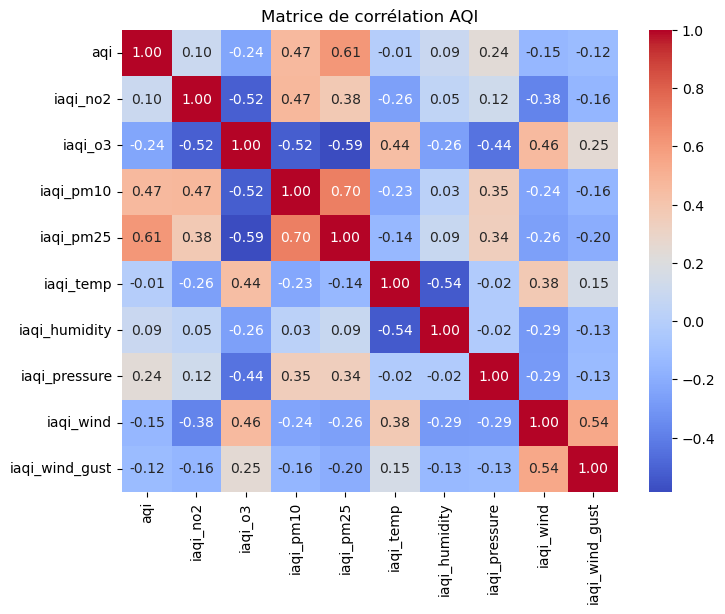

In [112]:


corr_matrix = df_corr.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation AQI")
plt.show()


In [113]:
df_model =  df[['aqi','iaqi_o3', 'iaqi_pm10','iaqi_pm25', 'iaqi_pressure']]

In [114]:


target = "aqi"
X = df_model.drop(columns=[target])
y = df_model[target]

# Enlève au minimum les lignes où la target est NaN
mask = y.notna()
X = X.loc[mask]
y = y.loc[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "LinearRegression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "DecisionTree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeRegressor(random_state=42))
    ]),
    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(random_state=42, n_estimators=300))
    ]),
    "GradientBoosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(random_state=42))
    ]),
}

scores = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    scores[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    trained_models[name] = model

scores

# --------- gagnant ---------

# Option B: R² le plus grand
best_model_name = max(scores, key=lambda k: scores[k]["R2"])

best_model = trained_models[best_model_name]
print("\nMeilleur modèle =", best_model_name)
print("Meilleurs scores =", scores[best_model_name])


Meilleur modèle = RandomForest
Meilleurs scores = {'MAE': 2.3037789914512117, 'RMSE': 6.853487982200934, 'R2': 0.8713147252527973}


In [115]:
y_pred_best = best_model.predict(X_test)

In [116]:
df_weather = pd.read_sql("SELECT * FROM fact_weather_records", conn)
df_weather.head()

/var/folders/tv/lm4xf58100z0w350rlffy8fr0000gn/T/ipykernel_12789/218157871.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_weather = pd.read_sql("SELECT * FROM fact_weather_records", conn)


,RECORD_ID,DT,DT_UTC,DT_PARIS,CITY_ID,WEATHER_ID,TEMPERATURE,FEELS_LIKE,TEMP_MIN,TEMP_MAX,...,HUMIDITY,SEA_LEVEL,VISIBILITY,WIND_SPEED,WIND_DEG,RAIN_1H,RAIN_3H,CLOUDINESS,SUNRISE,SUNSET
0,828f3a77112a80ae190f9c179651eb95,1771432203,2026-02-18 16:30:03+00:00,2026-02-18 17:30:03+00:00,09d053937cbeb3a31a2c0d113644cd42,803,12.50,12.10,12.50,12.71,...,88,1006,10000.0,5.66,130,NaN,None,75,2026-02-17 22:39:10,2026-02-18 09:18:00
1,4eaa256555af3fabd3482ea6f082d1ba,1771432293,2026-02-18 16:31:33+00:00,2026-02-18 17:31:33+00:00,845816a2178bc8475d2f00bcf332789d,804,8.80,7.02,8.80,8.80,...,93,1003,10000.0,3.09,210,NaN,None,100,2026-02-17 22:40:33,2026-02-18 09:07:18
2,5c72f8ef42c36534715890a8c3adbcf4,1771432291,2026-02-18 16:31:31+00:00,2026-02-18 17:31:31+00:00,2505f675e721c3c1f49da5f56b0ab45f,800,14.76,14.12,13.99,15.93,...,70,1008,10000.0,4.63,130,NaN,None,0,2026-02-17 22:32:44,2026-02-18 09:12:30
3,9cbf291964475b5683d0b912628b8fa4,1771432294,2026-02-18 16:31:34+00:00,2026-02-18 17:31:34+00:00,bbdedab5f8a07397e42ee51c6f52d8c1,800,11.90,10.92,11.03,12.56,...,68,1003,10000.0,7.72,170,NaN,None,0,2026-02-17 22:38:32,2026-02-18 09:10:32
4,eed98119b6755b12897fef8f36fca737,1771432293,2026-02-18 16:31:33+00:00,2026-02-18 17:31:33+00:00,bd04a10aceda3e0da2412874a27906cf,804,10.44,9.79,10.44,11.85,...,86,1007,10000.0,0.89,271,NaN,None,100,2026-02-17 22:34:15,2026-02-18 09:08:08


In [118]:
df_weather.columns = [c.lower() for c in df_weather.columns]
list(df_weather.columns)


['record_id',
 'dt',
 'dt_utc',
 'dt_paris',
 'city_id',
 'weather_id',
 'temperature',
 'feels_like',
 'temp_min',
 'temp_max',
 'pressure',
 'humidity',
 'sea_level',
 'visibility',
 'wind_speed',
 'wind_deg',
 'rain_1h',
 'rain_3h',
 'cloudiness',
 'sunrise',
 'sunset']

In [119]:
df_weather.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27389 entries, 0 to 27388
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   record_id    27389 non-null  object             
 1   dt           27389 non-null  int64              
 2   dt_utc       27389 non-null  datetime64[ns, UTC]
 3   dt_paris     27389 non-null  datetime64[ns, UTC]
 4   city_id      27389 non-null  object             
 5   weather_id   27389 non-null  int64              
 6   temperature  27389 non-null  float64            
 7   feels_like   27389 non-null  float64            
 8   temp_min     27389 non-null  float64            
 9   temp_max     27389 non-null  float64            
 10  pressure     27389 non-null  int64              
 11  humidity     27389 non-null  int64              
 12  sea_level    27389 non-null  int64              
 13  visibility   27350 non-null  float64            
 14  wind_speed   27389 non

In [122]:
df_corr_weather = df_weather[['temperature','humidity', 'wind_speed', 'pressure',
       'cloudiness', 'visibility']]

df_corr_weather.head()

,temperature,humidity,wind_speed,pressure,cloudiness,visibility
0,12.50,88,5.66,1006,75,10000.0
1,8.80,93,3.09,1003,100,10000.0
2,14.76,70,4.63,1008,0,10000.0
3,11.90,68,7.72,1003,0,10000.0
4,10.44,86,0.89,1007,100,10000.0


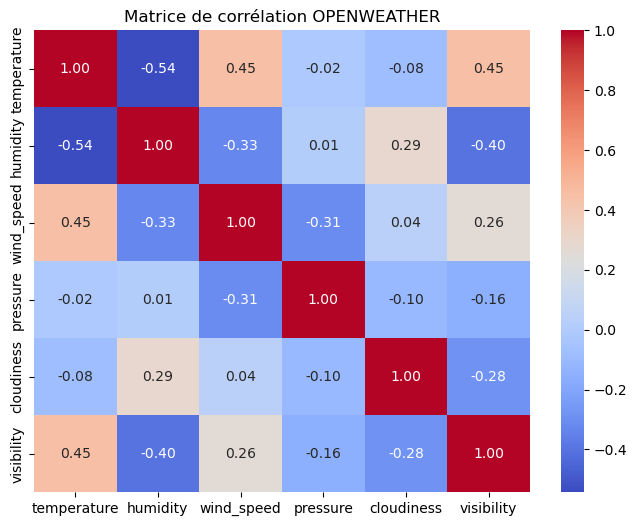

In [123]:
corr_matrix_weather = df_corr_weather.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix_weather, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation OPENWEATHER")
plt.show()